In [1]:
######## THIS CODE GIVES A MODEL FOR INFECTION AND THEN YOU CAN ADJUST THE COEFFICENTS USING LOCAL COEFFICENT ADJUSTMENT ########
###### HERE WE TEST THE EFFECT OF THE LOCAL COEFFICENT ADJUSTMENT ON THE LOW CASES SCENARIO ########################
########## PLEASE RUN THE CELLS IN ORDER ##############################################
######### Using this code you can regenerate Figure 13 #################################

####### Importing the required packages #######
using DataFrames
using CSV
using Plots
using ModelingToolkit, OrdinaryDiffEq, LinearAlgebra
using DifferentialEquations
using DataDrivenDiffEq
using DataDrivenSparse
using StatsPlots
using Statistics
using Distributions
using Dates
using DSP
using RecursiveArrayTools
using DiffEqParamEstim
using Optimization, OptimizationOptimJL
using OptimizationBBO, Optim
using ForwardDiff
using PenaltyFunctions
using Turing
using StableRNGs
using DataInterpolations
using ComponentArrays
using StatsBase
using Random
using Lux, SciMLSensitivity
using OptimizationOptimisers

In [8]:
#################### Making the Data #######################################
theme(:bright)
rng = StableRNG(20)

start_training=350
finish_training=680
##### specify the range you want to chop out for prediction
split_start= 500 
split_finish=split_start+28

begin
    raw_data=CSV.File("Thuringen_SIRD_2.csv") |> DataFrame
    data=Matrix(raw_data[:,[2, 3]])'
      
    s=size(data)[2]
    for i in 1:s
        data[1,i]=mean(data[1,max(1,i-5):min(s,i)])
    end
    ############# Beta distribution

    function factors(α, β, n) ## Beta distribution, coefficients for n days needed (Infected)
        d=Beta(α, β)
        max=pdf(d, mode(d))
        step=1/(n+2-1)
        steps=collect(0.0:step: 1.0)
        coefs=zeros(length(steps))
        for i in eachindex(coefs)
            coefs[i]=pdf(d,steps[i])/max
        end
        return steps[2:end-1], coefs[2:end-1]
    end

    n=21  #### number of days that infection rate of each patient changes
    vals, cofs=factors(2.5,4.5,n) #### α=1.5 and β=2.5, we can change the curve shape by changing α and β

    ###############################  factors should be  used ######################

    infectiveness=zeros(size(data)[2],1);
    infectiveness=DSP.conv(cofs, data[1,:])[1:length(infectiveness)]
   
    #smoothing the infectiveness
    for i in eachindex(infectiveness)
        infectiveness[i]=mean(infectiveness[max(i-4,1):min(end, i)])
    end

  
    data1=copy(data)
    data1[2,:]=infectiveness
    
    Max_data1=[maximum(data1[i,1:end]) for i in 1:size(data1)[1]]
    Min=0
    for i in 1:size(data1)[1]
        for j in 1:size(data1)[2]
            data1[i,j]=(data1[i,j]-Min)/(Max_data1[i]-Min)
        end
    end 
    
    data2=data1[:,start_training:split_start]
    data3=data1[:,split_finish:finish_training]
    
    X1=copy(data2);
    X2=copy(data3);
end

2×153 Matrix{Float64}:
 0.00712245  0.00759126  0.00786875  …  0.566087  0.5488    0.530753
 0.0102072   0.0100035   0.00982208     0.888634  0.874853  0.860613

In [9]:
############################# Making control signal ########################
begin
    v_raw_data=CSV.File("Thuringen_daily_vaccination.csv") |> DataFrame
    v_data=Matrix{Float64}(v_raw_data[:,3:5])'

   
    ####  weekly averaging
     avg_days=7
    s=size(v_data)
    weekly=Matrix{Float64}(undef,s[1], s[2])
    for i in 1:size(v_data)[1]
        weekly[i,:]=[mean(v_data[i, max(j-avg_days,1):j]) for j in 1:s[2]]'
    end
    #avg_days=7
   
    ############# beta distribution  

    n=35 ## number of days needed to reach the peak of antibody and then goes down after vaccination
    vvals, vcofs=factors(3,4,n) #### α=4 and β=4, we can change the curve shape by changing α and β


    ###############################  factors should be reversed and used ######################
    dose1=zeros(size(v_data)[2],1);
    dose2=zeros(size(v_data)[2],1);
    dose3=zeros(size(v_data)[2],1);

    vcofs1=reverse(reverse(vcofs))
    for i in 1:lastindex(dose1)
        for j in 1:min(n,i)-1
            dose1[i]=dose1[i] + weekly[1, i-j] * vcofs1[j]
            dose2[i]=dose2[i] + weekly[2, i-j] * vcofs1[j]
            dose3[i]=dose3[i] + weekly[3, i-j] * vcofs1[j]
        end 
    end

    dose11=zeros(size(raw_data)[1],1);
    dose21=zeros(size(raw_data)[1],1);
    dose31=zeros(size(raw_data)[1],1);

    difference=Dates.value(v_raw_data[1,1]-raw_data[1,1])
    
    for i in difference+1:lastindex(dose11)
        dose11[i]=dose1[i-difference]
        dose21[i]=dose2[i-difference]
        dose31[i]=dose3[i-difference]
    end

    antibody=dose11.+dose21.+ dose31
    
    Max_antibody=maximum(antibody)
    Min=0#minimum(v_data)
    for i in 1:size(antibody)[1]       
        antibody[i]=(antibody[i]-Min)/(Max_antibody-Min)
    end
    
    control=vcat(antibody'); 
    control1=vcat(antibody[start_training:split_start]');
    control2=vcat(antibody[split_finish:finish_training]');

end

1×153 Matrix{Float64}:
 0.53682  0.516833  0.496452  0.475869  …  0.78242  0.749704  0.718941

In [10]:
######################## definition and solving of the problem ##################
begin
    tick=100_000
    t1=collect(0.0:1/tick:(split_start-start_training)/tick);
    itp_method=InterpolationMethod(LinearInterpolation)

    sir_problem1=ContinuousDataDrivenProblem(X1, t1, itp_method, U = control1)

    t2=collect(0.0:1/tick:(finish_training-split_finish)/tick);
    
    final_data=(prob1=(X=X1, t=t1, itp_method, U=control1), prob2=(X=X2, t=t2,  itp_method, U=control2))
    sir_problem=ContinuousDataset(final_data)#(sir_problem1, sir_problem2

    @variables u[1:2] c[1:1]
    u = collect(u)
    c = collect(c)

    if start_training==1
        h = Num[polynomial_basis([u; c], 1);]# exp(c[1]);exp(c[2]);exp(c[3]);]
    else
        h = Num[polynomial_basis([u; c], 2);]
    end

    basis = Basis(h, u, controls=c)
    

    ### choosing STLSQ as an optimizer
    ### STLSQ is a sparsifying algorithm that cause the solve function to call its "Sindy" method ###
    opt = STLSQ(exp10.(-3:0.01:+5))


    #sampler = DataProcessing(split = 0.7, shuffle=true, batchsize = 30, rng = rng)

    options = DataDrivenCommonOptions(maxiters = 1000, 
                                  normalize = DataNormalization(ZScoreTransform),
                                  selector = bic, digits = 3)

    ddsol = solve(sir_problem, basis, opt, options=options);
   
end

"DataDrivenSolution{Float64}"

In [17]:
################## recovering the dynamic  ########################
window=6
begin
    ##### range of prediction ####
    newdays=window
    start=split_start+newdays
    finish=split_finish
    
    
    res=ddsol
    sys = get_basis(res)
    

    # Optimal parameters
    p_opt = get_parameter_values(sys)
    
    z0=data1[:,start]

    ztspan=(start/tick,finish/tick)

    u=control
    tsteps = range(0.0, 706/tick, length = 707)
    A=LinearInterpolation(u,tsteps);


    function get_dose1(t)
        return A(t)[1]
    end

    function get_total_antibody(t)
        down=control[1, Int(round(t*tick+1, RoundDown))]
        up=control[1, Int(round(t*tick+1, RoundUp))]
        down_co=t*tick-round(t*tick,RoundDown)
        up_co=1-down_co
        control_in_t=down_co*down+up_co*up
        return control_in_t
    end

    # Generate a closure on the system 
    f_recovered = let doese_1 = get_dose1
       (x, p, t) -> sys(x, p, t, [doese_1.(t)])
    end
    f_recovered1 = let doese_1 = get_total_antibody
        (x, p, t) -> sys(x, p.+p_opt, t, [doese_1.(t)])
    end    
end

#32 (generic function with 1 method)

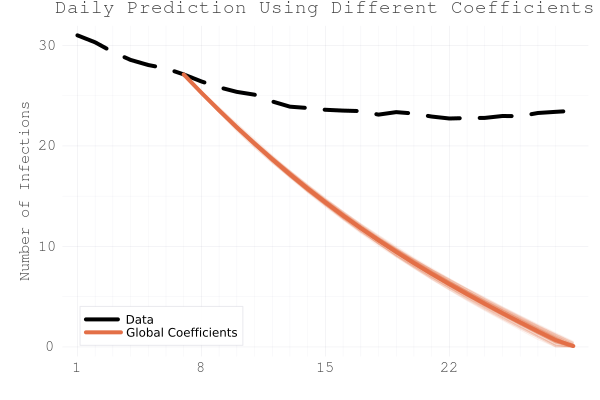

In [18]:
#################### Making projection using Global Coefficients #########################
ptest=plot(data1[1,start-window:finish]*Max_data1[1], label="Data", lw=4, color=:black, ls=:dash, title="Daily Prediction Using Different Coefficients",  legend=:bottomleft,
             yminorticks=2, xminorticks = 7, xticks=1:7:finish-start+1)
p_opt = get_parameter_values(sys)
begin
    theme(:bright)
    raw_data_end=CSV.File("Thuringen_SIRD_raw_2.csv") |> DataFrame
    data_end=Matrix(raw_data_end[:,[2, 3]])'
    t_step=1/tick
    beta=1.0
    
    g(u,p,t)=beta*u   #### stochastic function and its parameters

    ################## StatsPlots ################
    y1 = fill(NaN, finish-start+1, 1000);
    y2 = fill(NaN, finish-start+1, 1000);

    for i  in 1:1000
        prediction_prob = SDEProblem(f_recovered, g, z0, ztspan, p_opt)
        prediction = solve(prediction_prob, EM(), dt=t_step)
        M=Matrix(prediction)
      
        y1[:,i]=max.(M[1,:].-(z0[1]-data1[1,start]),0)       
        y2[:,i]=M[2,:]
        
    end
    
    ptest=errorline!(1+window:finish-start+1+window, y1[:,:]*Max_data1[1], errorstyle=:plume, label="Global Coefficients",
                     lw=4, left_margin = 5Plots.mm, bottom_margin = 5Plots.mm, ylabel="Number of Infections",
                     titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), 
                     ytickfont=font(8, "Arial"), xtickfont=font(8, "Arial"))
    
    
end

In [19]:
########### Local Coefficients Adjustment using 7 days of previous data points  #############
begin
    p1=get_parameter_values(sys);
    p=zeros(size(p1));
    prms=[];
    push!(prms, p1);
    window=6;
   
    new_data=data1[:,split_start:split_start+window];
    u0=data1[:,split_start];
   
    tspan=((split_start)/tick, (split_start+window)/tick);
    t=collect((split_start)/tick:1/tick:(split_start+window)/tick);
   
    problem=ODEProblem(f_recovered1, u0, tspan, p);


    ########## Objective Function for Optim.jl ##################
    cost_function=build_loss_objective(problem, Tsit5(), DiffEqParamEstim.L2Loss(t, new_data), 
                                        Optimization.AutoForwardDiff(),  Regularization(sum(abs.(p_opt))exp10(-30), L2Penalty()),
                                        maxiters=1000, verbose=false);

    ###### Optimization of the Parameter ###############################################
    optprob=Optimization.OptimizationProblem(cost_function, p);
    optsol=solve(optprob, BFGS());
    push!(prms, optsol.u.+ p1);

    params2=reduce(hcat, prms);

end

14×2 Matrix{Float64}:
  10258.2     10556.5
  -7953.61    -6943.24
 -10490.5    -10266.3
   6124.96     6882.91
    -71.989     -42.4432
   5959.27     5957.86
  -3063.52    -3063.54
  -5726.85    -5729.21
   6621.25     6621.19
  -3324.77    -3324.91
    280.478     268.311
    723.682     722.415
    481.667     479.09
   -322.852    -356.895

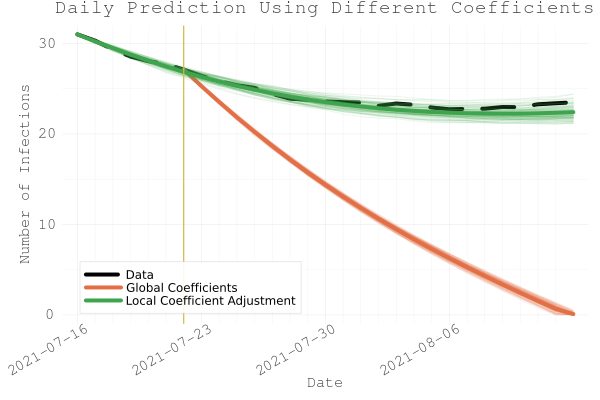

In [ ]:
#################### making projection using the Locally adjusted Coefficients #########################
######## Figure 13 ######
start = split_start
z0=data1[:,start]
ztspan=(start/tick,finish/tick)


dates=raw_data[start:finish+1,1];
p_opt2=params2[:,2]#optimised parameters
begin
    theme(:bright)
    raw_data_end=CSV.File("Thuringen_SIRD_raw_2.csv") |> DataFrame
    data_end=Matrix(raw_data_end[:,[2, 3]])'
    t_step=1/tick
    beta=1.0
    
    g(u,p,t)=beta*u   #### stochastic function and its parameters

    ################## StatsPlots ################
    y1 = fill(NaN, finish-start+1, 1000);
    y2 = fill(NaN, finish-start+1, 1000);
  
    for i  in 1:1000
        prediction_prob = SDEProblem(f_recovered, g, z0, ztspan, p_opt2)
        prediction = solve(prediction_prob, EM(), dt=t_step)
        M=Matrix(prediction)

        y1[:,i]=max.(M[1,:].-(z0[1]-data1[1,start]),0)

        y2[:,i]=M[2,:]

    end

    ptest=errorline!(1:finish-start+1, y1[:,:]*Max_data1[1], errorstyle=:plume, label="Local Coefficient Adjustment", 
                     lw=4, left_margin = 5Plots.mm, bottom_margin = 5Plots.mm, ylabel="Number of Infections",
                     titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), 
                     ytickfont=font(8, "Arial"), xtickfont=font(8, "Arial"))

end
plot!(ptest,xformatter= x->Dates.format(dates[Int(round(x+1, RoundDown))], "yyyy-mm-dd"), xrot=30, xlabel="Date")
plot!([window+1], seriestype=vline, label=false)